In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("healthcare-dataset-stroke-data.csv")
print(f"Veri Setinin Boyutu: {data.shape}")
data.head()

Veri Setinin Boyutu: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [5]:
data.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

### Katagorik Değişkenlerin incelenmesi

- gender (Cinsiyet): Veri setinde kadın baskınlığı var en yüksek değere sahip sınıf ardından Erkekler ve en son olarak çok küçük bir değere sahip Other geliyor model bu sınıfı gürültü olarak algılayabilir

- ever_married (Evlilik): Evli kişilerin sayısı evlenmemiş olanların sayısının nerdeyse iki katı bu modelin evli insanlara karşı yanlı olmasına neden olabilir

- residence_type (İkamet): Dengeli bir dağılım söz konusu kentte ve kırsalda yaşayan kişi sayısı nerdeyse birbirine eşit

- work_type (Çalışma): burada 'Private'(Özel sektör) bariz bir baskınlığa sahip verinin çoğunluğunu oluşturuyor hiç çalışmayanlar ise en az değere sahip sınıf diğer sınıflar birbirine yakın değerlere sahip

- smoking_status (sigara): en baskın sınıf sigara içmeyen kişiler ardından ise sigara içtiği bilinmeyen insanlar geliyor bu sorun teşkil ediyor çünkü sigara içenler ve içmeyenler net ayırt edilemiyor ve hastalığa etkisinin net tespitini zorlaştırır eskiden içen ve hala içmekte olan kişiler birbirine yakın

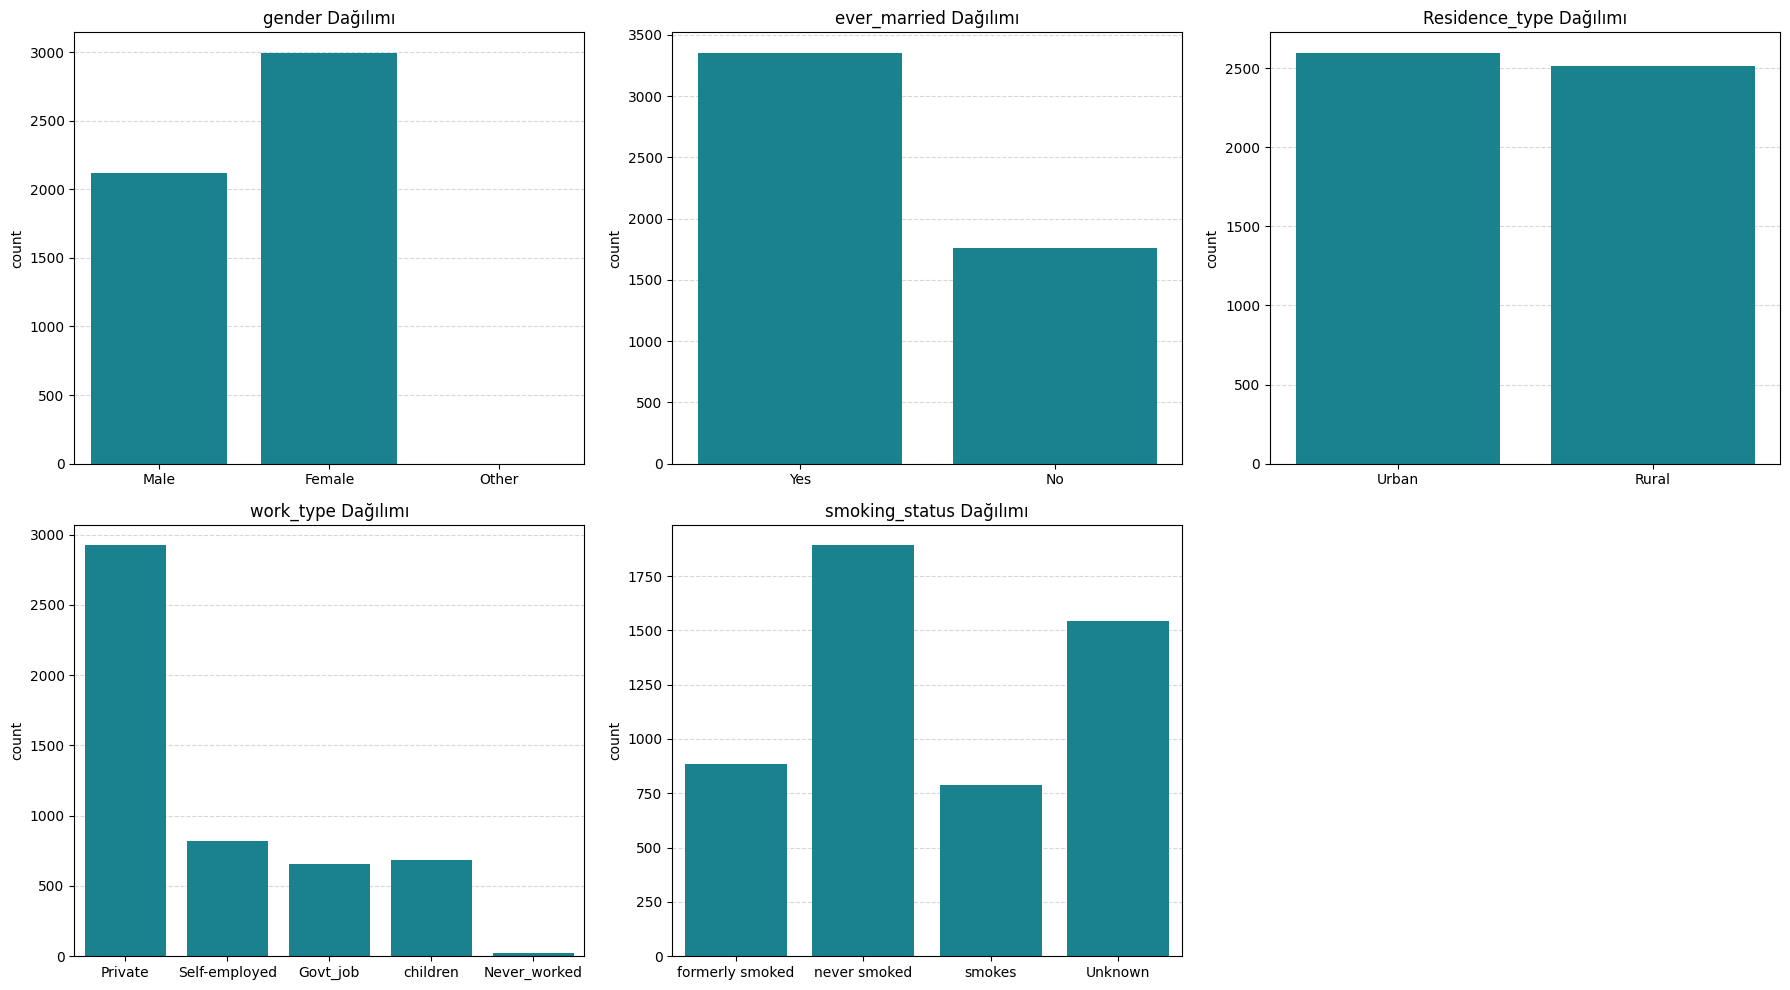

In [6]:
cat_col = ['gender', 'ever_married', 'Residence_type', 'work_type','smoking_status']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, col in enumerate(cat_col):
    sns.countplot(x=data[col], color='#0792a1a9', zorder=2, ax=axes[i])
    axes[i].grid(axis = 'y',linestyle='--', alpha = 0.5)
    axes[i].set_title(f'{col} Dağılımı')
    axes[i].set_xlabel('') # alt etiketleri temizler

fig.delaxes(axes[5])
plt.tight_layout() # Grafikler birbirine girmesin diye araları açar
plt.show()

### katagorik değişkenler ile stroke bağımlı değişkenin karşılaştırılması
- cinsiyete baktığımızda iki ayrı gurupta kadınların daha fazla felç geçirdiğini görüyoruz ama önceki analizde veri setinde kadınların erkeklerden daha fazla olduğunu gördük bunu göz önünde bulundurduğumzda bunun normal olduğu anlaşılıyor yani veri seti bazında cinsiyetin belirleyici bir özellik olmadığını söyliyebiliriz

- Evlilik : bu değişkende de belirleyici bir gözlem bulunmuyor ama evlenmeyenlerde felce yakalanma daha az eşit gözlemlerde bu anlaşılır
- ikamet: şehir ve kırsalda felce yakalanma nerdeyse eşit duruyor bu değişkenden çıkarımda bulunmamızı zorlaştırıyor
- çalışma şekli: işin felç hastalığı üzerinde  belirleyici bir özelliği yok gibi duruyor sınıf oranına göre felç durumunun düzgün olduğunu görebiliyoruz
- sigara içme durumu en fazla felç durumunu en büyük sınıfımız olan hiç sigara içmemiş kişilerde görüyoruz ama bu değişkende diğerlerinden farklı olarak sigara içen ve önceden içmiş kişilerde sınıf oranın diğerlerine nazaran olmasına rağmen yüksek felç geçirme durumu görülüyor bu da kesinlikle sigara içip içmemenin felç üzerinde etkisi olduğunu anlamamızı sağlıyor

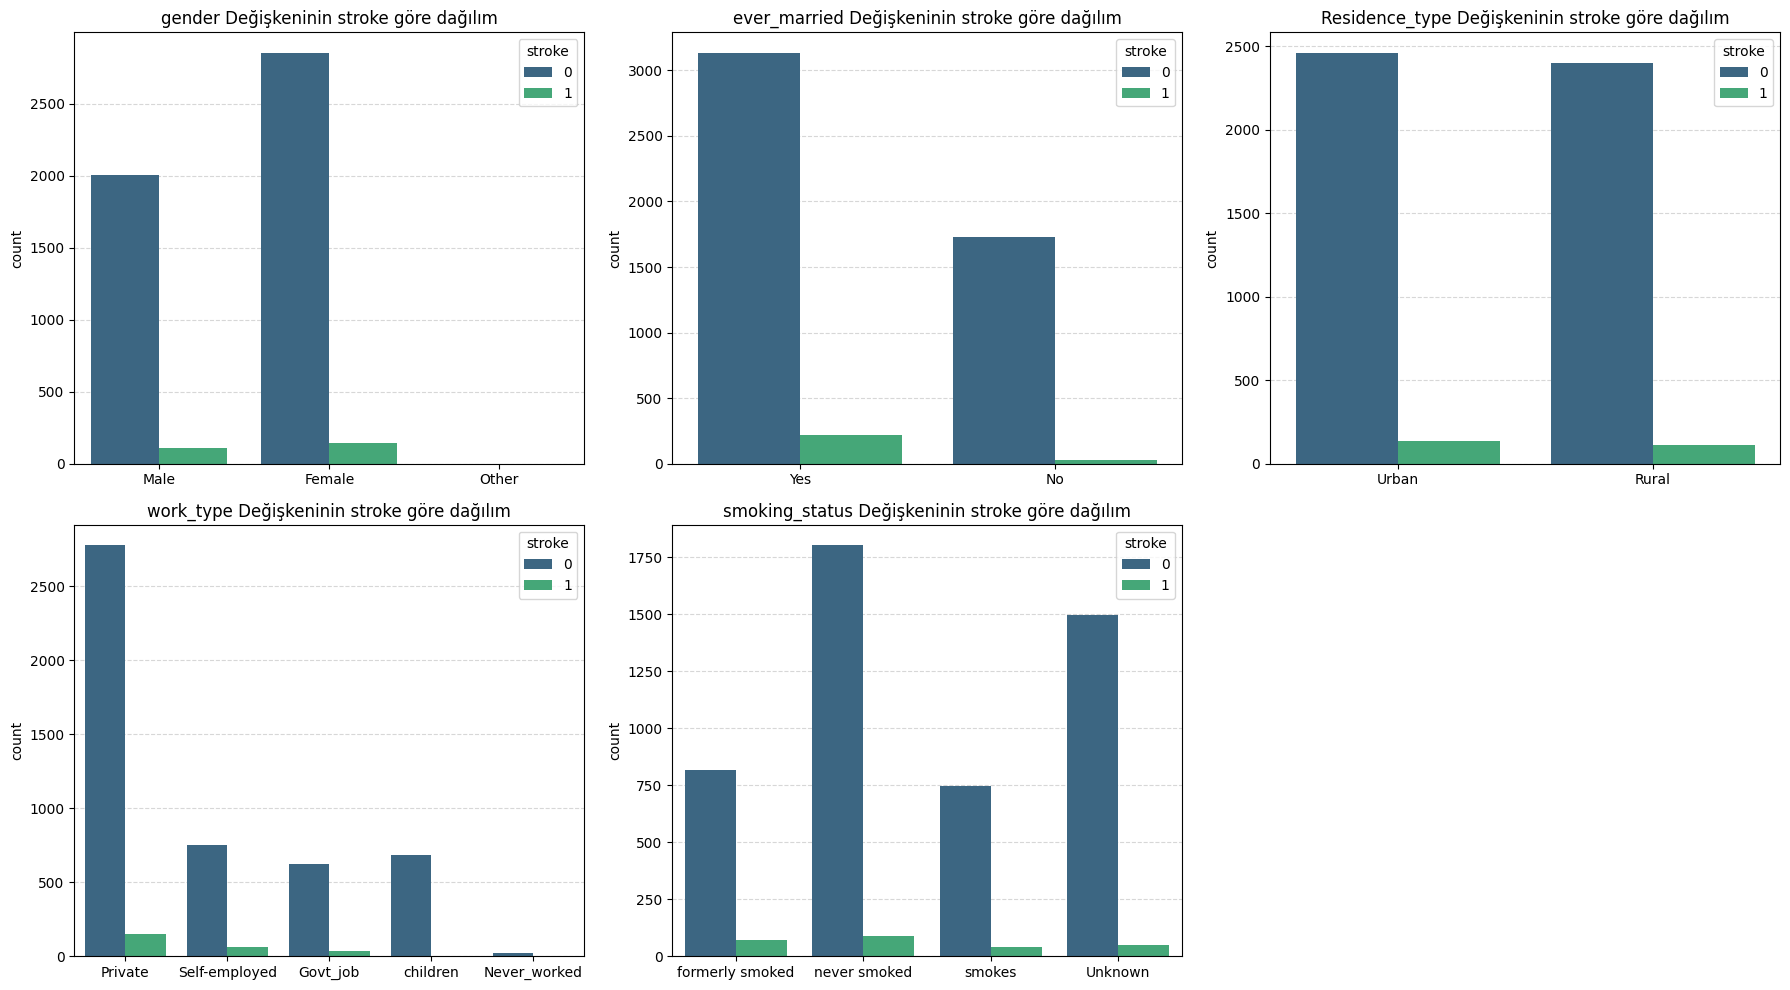

In [7]:
# hue bağımlı değişken seçmemizi sağlıyor bu sayede katagorik değişkenler ile stroke karşılaştırıyoruz
# hue kullanınca palette kullanmalısn 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    sns.countplot(data=data, x=col,hue='stroke', palette='viridis', zorder=2, ax=axes[i]) 
    axes[i].grid(axis = 'y',linestyle='--', alpha = 0.5)    
    axes[i].set_title(f'{col} Değişkeninin stroke göre dağılım')
    axes[i].set_xlabel('')  

fig.delaxes(axes[5])
plt.tight_layout()  
plt.show()

### Nümerik verilerin İncelenmesi

- age (Yaş): Dağılım genel olarak tüm yaş guruplarını kapsasa da homojen değildir veri 80 yaş civarında bir tepe noktası(pik) yapmakta bu da örneklemde yaşlı nüfusun beligin bir ağırlığı oldğunu gösterir

- avg_glucose_level (Şeker): belirgin şekilde sağa çarpık bir yapıdadır. normal seviyelerdeki 50-100 yığılmanın yanı sıra sağ tarafta diyabet sınırını aşan uzun bir kuyruk mevcut bu çarpıklık ve medyan değerleri arasında ciddi bir fark olduğunua işaret eder

- bmi (Vücut Kitle İndeksi): Dağılım sağa çarpıktır. verinin büyük kımı 25-35 aralığında toplanmış olsa da obezite sınırını aşan uç değerler sağa doğru kuyruk oluşturmuştur bu nedenle eksik verilerin doldurulmasında ortalama yerine medyan tercih edilecektir

- hastalık durumları (Stroke, Hypertension, Heart Disease): Her üç değişkende de 0 (hastalık yok) sınıfı ezici bir çoğunluğa sahip ve bu durum veri setinde ciddi bir sınf dengesizliği olduğunu kanıtlar hastalıkların görülme sıklığının az olması modelin "hastalık yok" tahminine aşırı odaklanmasına neden olabilir

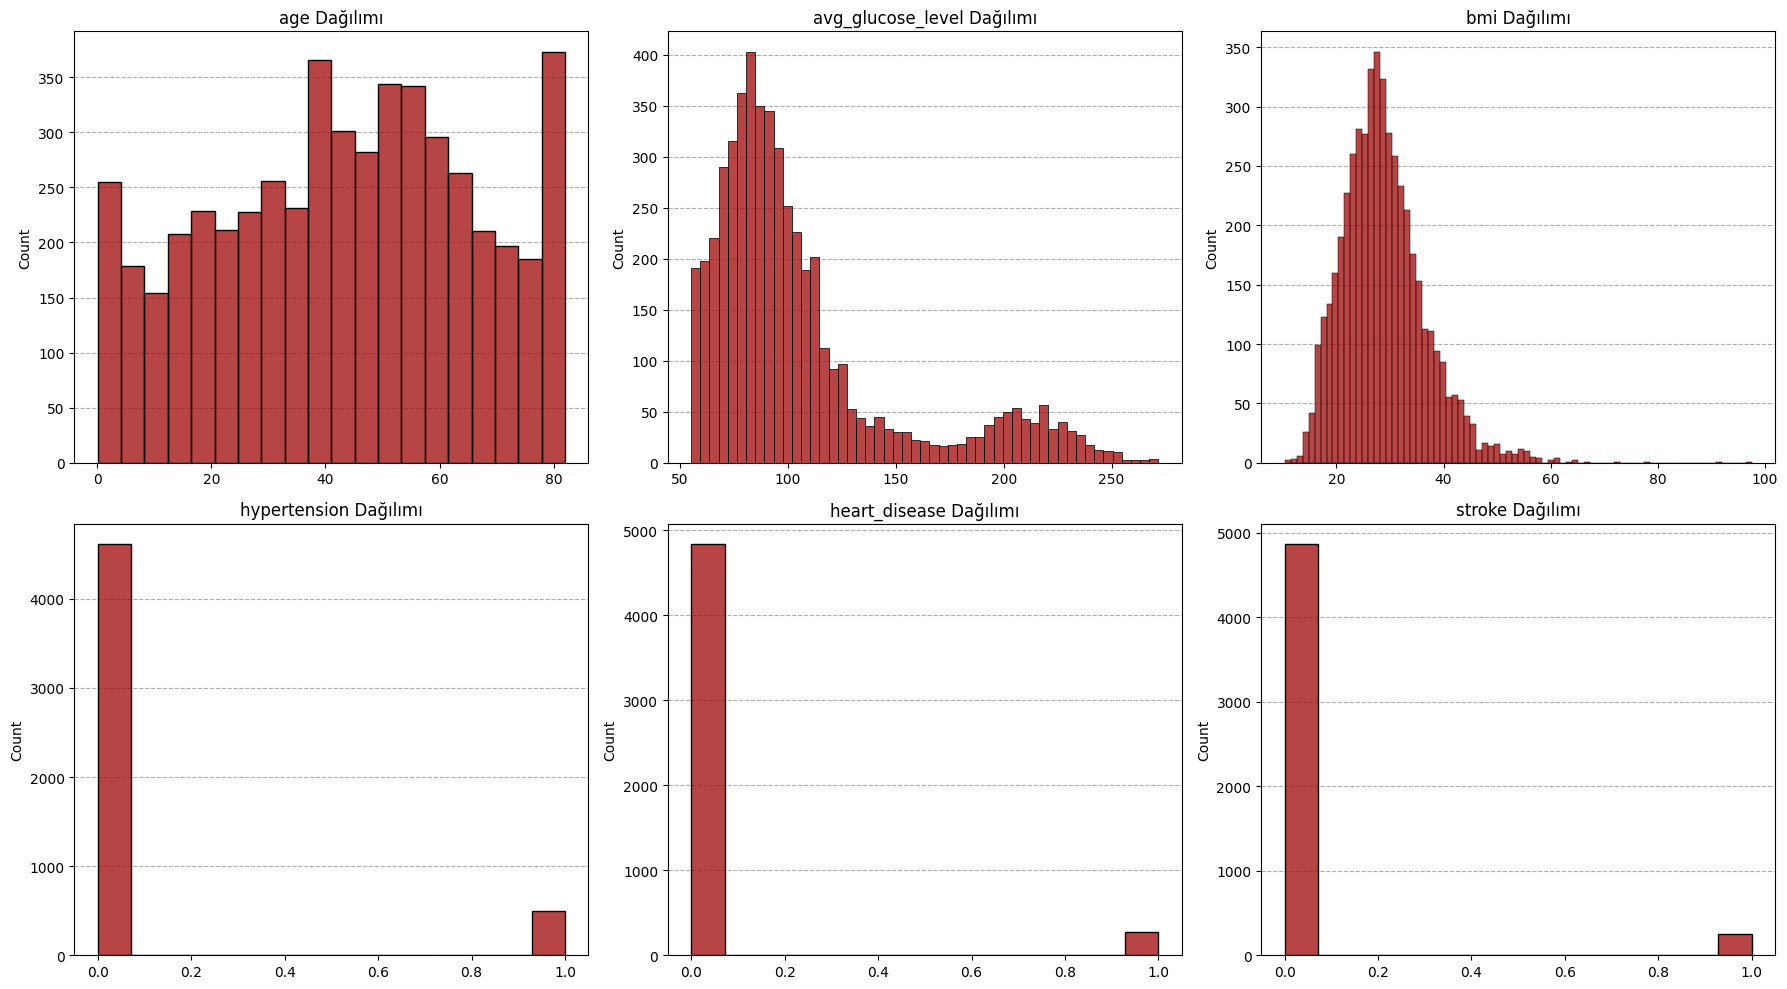

In [8]:
num_col = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.histplot(x=data[col], color="#a10707a9", zorder=3, ax=axes[i])
    axes[i].grid(axis='y', linestyle='--', zorder=0)
    axes[i].set_title(f'{col} Dağılımı')
    axes[i].set_xlabel('')



plt.tight_layout()  
plt.show()

In [9]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Kutu Grafiği Yorumu
- Yaş değişkeni: genel çıkarım veride medyan Q3 değerine daha yakın bu da yaşın daha çok sağ tarafa yani büyük değerlere sahip olduğunu gösteriyor veri setinde yaşlı insanlar daha baskın ayrıca felç geçiren kırmızı renk kutuda üst veri üst bıyığa daha yakın yani yaş arttıkça felç geçirme artıyor felç geçirmeyen insanlar ise daha genç gri kutudan anlaşılıyor ve ayrıca min-max iyi yayılmış veri tam ortada bulunuyor ayrıca felç geçirenlerde iki aykırı değer bulunuyor bunlar genç yaşta felç geçirmiş kişiler ama yaş ile alakalı değil geçirilen bir kaza veya başka bir hastalık yüzünden felç geçirmiş olabilirler ayrıca kırmızı kutuya tekrar dönecek olursak medyan Q3 ve max değere oldukça yakın bu sola çarpık verinin işareti ama daha önceki gözlemlerden yaş normal dağılmadığı ve homojene yakın olduğundan bunu normal karşılayabiliriz

- şeker ölçümü: felç geçrirmemiş kişilerde fazla aykırı değer bulunmakta yani felç geçirmemesine rağmen kişide fazla şeker ölçümü gözlenebiliyor bu yemekten sonra ölçülmüş şeker değerleri olabilir ama yemekten sonra ölçülmüş olabilir böyle olsabile sağlıklı bir insanda bulunan şeker düzeyinden çok daha yüksek şeker ölçümleri bulunmakta yani eğer 200 değerinden sonraki kişileri şeker hastası olarak ele alırsak baya bir kişinin felç geçirmemesine rağmen şeker hastsı olduğunu düşünebiliriz ayrıca felç geçirmeyenlerde normal şeker düzeyi 50-150 arasında bulunuyor ölçümün bilinmemesinden bu aralığı sağlıklı kişilerin bulunduğu aralık olarak ele alabiliriz kırmızı yani felç geçirenlerin şeker düzeylerini ele aldığımızda çok geniş bir aralığa yayıldıklarını görebiliriz sağlıklıdan 200 değerine kadar yani sağlıksız şeker düzeyine kadar yani tam olarak şeker düzeyinin felç geçirme üzerindeki etkisi belirli değil felç geçirenlerde medyan 1.çeyrekliğe daha yakın verinin çoğunluğu bu kısımda bulunuyor min-max değerler arasında büyük bir açıklık bulunuyor yani çok yüksek şeker düzeylerine sahip kişilerde felç gözlenebiliyor verinin sağa çarpık olması ve min-max değerler arsındaki fark yüksek olduğundan bu değişkenin daha detaylı ele alınması gerekiyor

- vücut kitle endeksi: felç geçiren ve geçirmeyen sınıflar bakıldığında iki sınıfta da bmi bazında aykırı değerlerrin bulunduğunu 18-24 değerini sağlıklı ölçüm aralığı olarak elealırsak ve önceki histogramı da göz önünde bulundurarak sağlıklı insanların yani normal seviyede bulunanların felce yakalanma ihtimalinin daha az olduğunu felce yakalanan kişilerin ise kilolu, obezite hastalıklarına sahip olduğunu söyleyebiliriz değişkenimiz sağa çarpık olsada iki sınıf için medyanların oratada bulunduğunu görüyoruz çıkarabileceğimiz en mantıklı görü felç geçirenlerin sağlıklı bmi değerlerine sahip olmadıkları ayrıca felç geçirmeyenler arasında yüksek kilolara sahip olmalarına rağmen hastalığıa yakalanmıyan kişilerin fazla odluğudur 

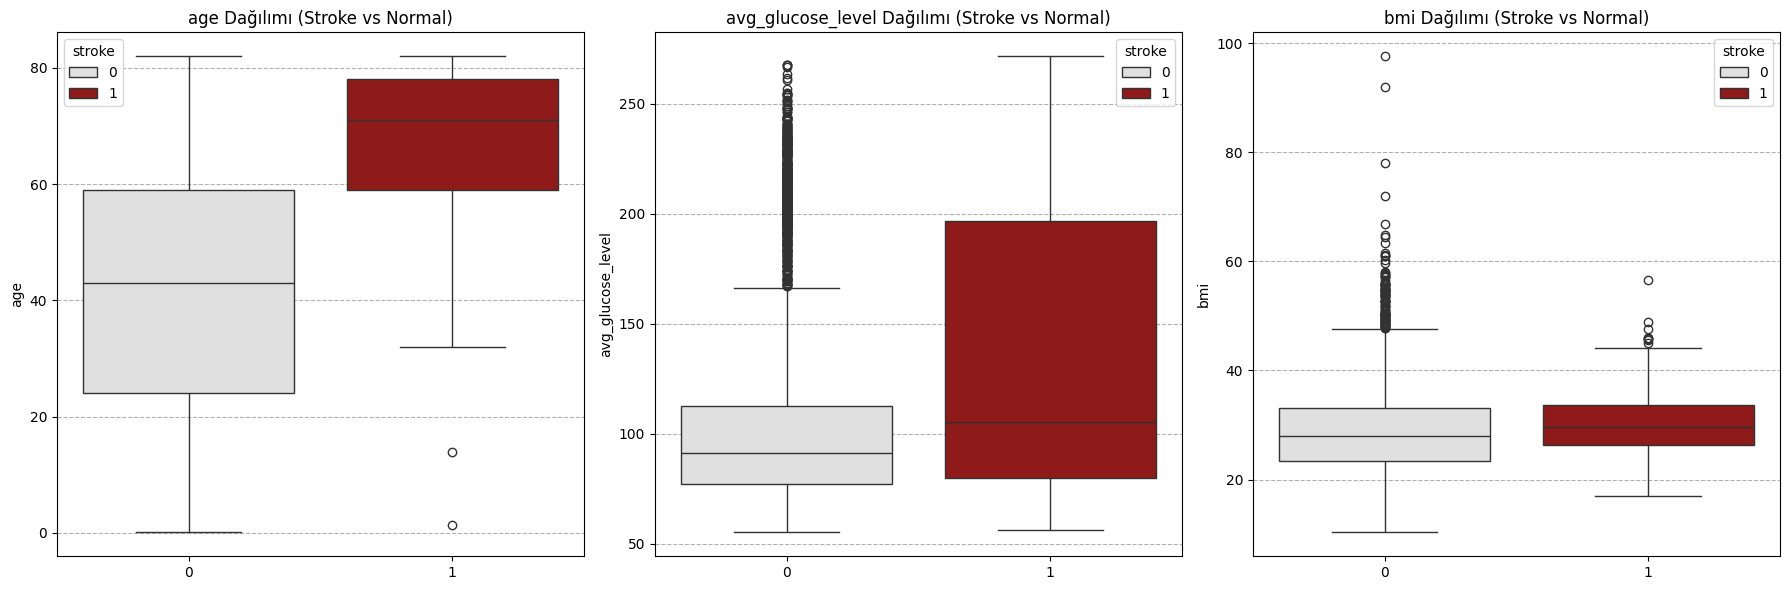

In [10]:
num_col = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()
my_red = "#a10707a9"  # Senin histogram rengin
custom_colors = ["#e0e0e0", my_red] 
palette = sns.color_palette(custom_colors)

for i, col in enumerate(num_col):
    sns.boxplot(data=data, x='stroke',hue='stroke', y= col, palette=palette, ax=axes[i])
    axes[i].set_title(f'{col} Dağılımı (Stroke vs Normal)')
    axes[i].grid(axis='y', linestyle='--', zorder=0)
    axes[i].set_xlabel('')
plt.tight_layout()    
plt.show()

# Korelasyon 

- ilk olarak bağımlı değişkenin bağımsız değişkenler ile olan ilişkilerine baktığımızda genel olarak düşük ilişki görüyoruz en çok ilişkiye sahip değişken yaş değişkeni o da 
0.25 civarında yeterince anlamlı bir değişken değil genel gözlem: değişkenlerin arasında yeterli ilişki olmaması modelleme için iyi modelimizin bias-varyans oranını koruyarak iyi tahminler yapmamızı sağlar bu aşamada değişkenlerin tamamamına baktığımızda yaş değişkeninde diğerlerine nazaran daha fazla değer gözleniyor en yüksek değer bmi de ardından hipertansiyon geliyor model seçimi olarak k-en yakın komşu veya ağaç tabanlı modeller seçilebilir ağaç tabanlı modeller yüksek ilişkili modellerde iyi sonuç verdiği gibi düşük ilişkili modellerde de iyi sonuç verirler 
- doğrusal ilişkinin az olmasının sebepleri değişkenlerin çarpık olaması kalp hastalığı, hipertansiyon ve felç hastalıklarında 0 değerinin daha çok gözlenmesi yani sınıf dengesizliği olması ve aykırı değerler gibi bir çok etmen olabilir bunlar için normalizasyon veya düzgün model seçmek aykırı değerleri gidermek eksik değerlerin düzeltilmesi gibi çeşitli özellik mühendisliği işlemleri yapılabilir
- kısaca doğrusal ilişkinin az olması verinin çarpık olması gibi durumları göz önünde bulundurarak nonlineer modellerin en iyi sonuç vereceği görülmekte 

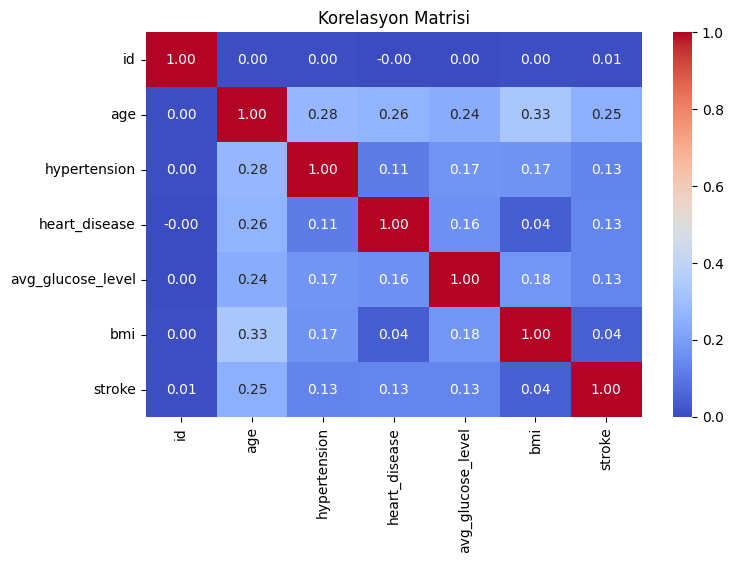

In [11]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(8, 5))
sns.heatmap(data=corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasyon Matrisi')
plt.show()